<a href="https://colab.research.google.com/github/ikeita1114-blip/rudesalud-site/blob/main/Report/IMISToolA2026_Report4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Report 4 (2026/07/27 ver.A)

for Tools for intelligent interaction systems a (0ALE005 / 0AL5707).

---

* 202620740: (E.g. 202099998)...Erase-and-put-yours-here
* 磯野圭大: (E.g. 筑波 太郎）...Erase-and-put-yours-here
* ikeita1114@gmail.com: (E.g. tsukuba.taro.xs@alumni.tsukuba.ac.jp)...Erase-and-put-yours-here

---

Report could be written in English or Japanese. / レポートの記述は日本語でも英語でもよい．

---

---
# Report4A: Live capture query with CIFAR-10 or MNIST  

* Show the way to build a classfier of CIFAR10 or MNIST.
* Provide a python program that captures an image from a camera and that shows its recognition result of the image immediately.

Hint: Each shown in tutorials. Find a way to unite them.



In [ ]:
print ('You can put code cells and text cells around here.')

In [12]:
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 乱数を固定
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# GPUが使える場合はGPUを利用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("使用デバイス:", device)
print("PyTorch version:", torch.__version__)


使用デバイス: cpu
PyTorch version: 2.11.0+cpu


In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=256,
    shuffle=False
)

print("学習データ数:", len(train_data))
print("テストデータ数:", len(test_data))

学習データ数: 60000
テストデータ数: 10000


In [14]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = MNISTCNN().to(device)

print(model)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [15]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 3

for epoch in range(epochs):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {total_loss / len(train_loader):.4f}, "
        f"Accuracy: {accuracy:.2%}"
    )

Epoch 1/3, Loss: 0.1925, Accuracy: 94.02%
Epoch 2/3, Loss: 0.0563, Accuracy: 98.29%
Epoch 3/3, Loss: 0.0377, Accuracy: 98.81%


In [7]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total

print(f"テストデータの正解率: {test_accuracy:.2%}")

テストデータの正解率: 98.96%


In [8]:
from base64 import b64decode
from google.colab.output import eval_js
from IPython.display import Javascript, display

In [9]:
def take_photo(filename="captured_digit.jpg", quality=0.9):

    js = Javascript("""
    async function takePhoto(quality) {

        const div = document.createElement('div');

        const video = document.createElement('video');
        video.style.width = '500px';
        video.setAttribute('playsinline', '');

        const button = document.createElement('button');
        button.textContent = '撮影';
        button.style.fontSize = '18px';
        button.style.margin = '10px';
        button.style.padding = '8px 20px';

        const message = document.createElement('p');
        message.textContent =
          '白い紙に黒いペンで書いた数字を中央に映してください。';

        div.appendChild(message);
        div.appendChild(video);
        div.appendChild(button);

        document.body.appendChild(div);

        const stream =
          await navigator.mediaDevices.getUserMedia({
              video: true
          });

        video.srcObject = stream;

        await video.play();

        google.colab.output.setIframeHeight(
            document.documentElement.scrollHeight,
            true
        );

        await new Promise(
            resolve => button.onclick = resolve
        );

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas
          .getContext('2d')
          .drawImage(video, 0, 0);

        stream.getVideoTracks()[0].stop();

        div.remove();

        return canvas.toDataURL(
            'image/jpeg',
            quality
        );
    }
    """)

    display(js)

    data = eval_js(
        f"takePhoto({quality})"
    )

    image_data = b64decode(
        data.split(",")[1]
    )

    with open(filename, "wb") as file:
        file.write(image_data)

    return filename

In [10]:
def preprocess_camera_image(filename):

    # 画像を読み込む
    image_bgr = cv2.imread(filename)

    if image_bgr is None:
        raise FileNotFoundError(
            "撮影画像を読み込めませんでした。"
        )

    # 表示用のRGB画像
    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    # グレースケール化
    gray = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2GRAY
    )

    height, width = gray.shape

    # 画像中央部分を切り出す
    crop_size = int(
        min(height, width) * 0.7
    )

    x_start = (
        width - crop_size
    ) // 2

    y_start = (
        height - crop_size
    ) // 2

    cropped = gray[
        y_start:y_start + crop_size,
        x_start:x_start + crop_size
    ]

    # ノイズを減らす
    blurred = cv2.GaussianBlur(
        cropped,
        (5, 5),
        0
    )

    # 白い背景と黒い数字を反転する
    _, binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV
        + cv2.THRESH_OTSU
    )

    # 輪郭を検出
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        raise ValueError(
            "数字を検出できませんでした。"
        )

    # 最も大きな輪郭を数字として扱う
    contour = max(
        contours,
        key=cv2.contourArea
    )

    x, y, w, h = cv2.boundingRect(
        contour
    )

    digit = binary[
        y:y + h,
        x:x + w
    ]

    # 数字を正方形へ配置
    side = max(w, h)

    square = np.zeros(
        (side, side),
        dtype=np.uint8
    )

    offset_x = (
        side - w
    ) // 2

    offset_y = (
        side - h
    ) // 2

    square[
        offset_y:offset_y + h,
        offset_x:offset_x + w
    ] = digit

    # 20×20画素へ縮小
    resized = cv2.resize(
        square,
        (20, 20)
    )

    # 28×28画素の中央へ配置
    mnist_image = np.zeros(
        (28, 28),
        dtype=np.uint8
    )

    mnist_image[
        4:24,
        4:24
    ] = resized

    # PyTorchのテンソルへ変換
    tensor = torch.from_numpy(
        mnist_image
    ).float()

    tensor = tensor / 255.0

    tensor = (
        tensor - 0.1307
    ) / 0.3081

    tensor = tensor.unsqueeze(0)
    tensor = tensor.unsqueeze(0)

    return (
        image_rgb,
        binary,
        mnist_image,
        tensor
    )

<IPython.core.display.Javascript object>

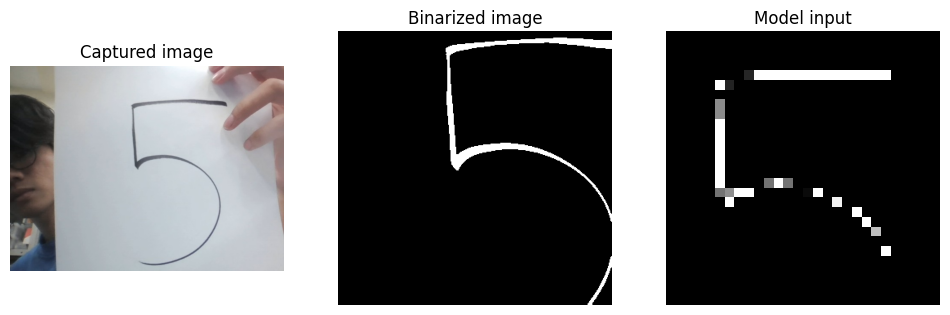

認識結果: 5
確信度: 81.19%
各クラスの確率
0: 0.03%
1: 0.09%
2: 1.39%
3: 1.54%
4: 0.22%
5: 81.19%
6: 1.24%
7: 0.40%
8: 9.84%
9: 4.05%


In [16]:
def capture_and_predict():

    # カメラで撮影
    filename = take_photo()

    # 前処理
    original, binary, mnist_image, tensor = (
        preprocess_camera_image(filename)
    )

    # 分類
    model.eval()

    with torch.no_grad():

        outputs = model(
            tensor.to(device)
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[0]

    probabilities = (
        probabilities
        .cpu()
        .numpy()
    )

    predicted_digit = int(
        np.argmax(probabilities)
    )

    confidence = float(
        probabilities[predicted_digit]
    )

    # 画像を表示
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Captured image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(binary, cmap="gray")
    plt.title("Binarized image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(
        mnist_image,
        cmap="gray"
    )
    plt.title("Model input")
    plt.axis("off")

    plt.show()

    # 結果表示
    print(
        "認識結果:",
        predicted_digit
    )

    print(
        "確信度:",
        f"{confidence:.2%}"
    )

    print("各クラスの確率")

    for digit, probability in enumerate(
        probabilities
    ):
        print(
            f"{digit}: "
            f"{probability:.2%}"
        )


capture_and_predict()

(You can put text cells around here)

---
# Report4B: Tutorials of pytorch

There are [many tutorials](https://github.com/kameda-yoshinari/IMISToolExeA2021/blob/master/300_PyTorch.ipynb) provided by the Pytorch official site. Pick up **two tutorials** (you should complete those tutorials) and make a report for the two tutorials on:

* Summary (2-3 lines)
* What you learn
* The most difficult part

Note that you are encouraged to choose the recommended two .


1つめ　Quickstart

Summary

このチュートリアルでは、FashionMNISTデータセットを使用し、データの読み込み、ニューラルネットワークの構築、モデルの学習と評価、学習済みモデルの保存と読み込みまでを実行した。PyTorchを用いた画像分類の基本的な流れを一通り確認できた。

What you learn

このチュートリアルを通して、DatasetとDataLoaderを利用して、画像と正解ラベルをミニバッチ単位で読み込む方法を学んだ。また、モデルの出力と正解ラベルから損失を求め、誤差逆伝播によってモデルのパラメータを更新する流れを理解した。
学習時にはmodel.train()、評価時にはmodel.eval()へ切り替える必要があることも学んだ。さらに、評価時にtorch.no_grad()を使用することで、不要な勾配計算を停止できることを確認した。

The most difficult part

最も難しかった部分は、学習処理における勾配計算とパラメータ更新の流れである。特に、optimizer.zero_grad()、loss.backward()、optimizer.step()をどの順番で実行するのかを理解することが難しかった。

２つめ　Build the Neural Network

Summary

このチュートリアルでは、torch.nn.Moduleを継承して独自のニューラルネットワークを作成した。Flatten、Linear、ReLUなどの層を組み合わせ、入力画像から10クラス分の予測値を出力する処理を確認した。

What you learn

PyTorchでは、ニューラルネットワークをnn.Moduleのサブクラスとして定義することを学んだ。__init__()ではモデルが使用する層を準備し、forward()では入力データがそれらの層を通過する順番を記述する。
また、nn.Sequentialを使用すると、複数の層を実行順にまとめられることを理解した。画像データを全結合層へ入力する前には、nn.Flattenを使って多次元の画像を1次元のベクトルに変換する必要があることも学んだ。

The most difficult part

最も難しかった部分は、各層を通過した後のテンソルの形状を理解することである。全結合層のnn.Linearでは、入力する特徴量の数を正しく指定する必要があり、入力サイズが一致しない場合には行列計算に関するエラーが発生する。
そのため、入力画像の形状と、Flatten後の要素数がどのように変化するかを確認しながらモデルを作成することが重要だと感じた。





---
# Report4C: AI support to learn python and PyTorch  

Find out the state-of-the-art AI support which is available / helpful on learning how to write python / pytorch codes on google colab.
Then write your own comment on what kind of changes would happen in a couple of years.

* AI service name
* AI service "official web site"
* Major funcitons of provided support
* The service start date and version history (including the URL that holds such info)


(You can put text cells around here)

---
# Report submission

As for Report4, in addition to submit this ipynb, you are also asked to submit 801_miniGPT.ipynb and 802_miniGPT.ipnyb (in total of three files).

You should save this file as a report templete to your local google colaboratory folder and then edit it to fit your report.

The report submission should be made at this cource (0ALE005) at https://manaba.tsukuba.ac.jp .  
Note that 0AL5707 is coupled with 0ALE005 on manaba system, so 0AL5707 students should also submit the report at 0ALE005.  
File extension should be **ipynb**. Other format won't be accepted.  







---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/07/27. Ver.B. 説明簡略化 / Simplified Explanation  
2026/07/27. Ver.A.  


